# Лабораторная работа № 7

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (silhouette_score, accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay)
from processing import preprocess_data

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = preprocess_data(df)

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Задания 1 и 2. Обучение моделей и оптимизация гиперпараметров

### Подбор параметров для Decision Tree

In [4]:
algos = [DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier]

In [5]:
algos = {
    "DecisionTreeClassifier": {
        "algo": DecisionTreeClassifier,
        "param_grid": {
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 5, 10, 15, None],
            'max_features': ['sqrt', 'log2', None]
        }
    },
    "RandomForestClassifier": {
        "algo": RandomForestClassifier,
        "param_grid": {
            'criterion': ['gini', 'entropy'],
            'max_depth': [5, 10, 15, None],
            'max_features': ['sqrt', 'log2', None]
        }
    },
    "GradientBoostingClassifier": {
        "algo": GradientBoostingClassifier,
        "param_grid": {
            'loss': ['log_loss'],
            'n_estimators': [100],
            'max_depth': [3, 5, 7],
            'max_features': ['sqrt', 'log2', None]
        }
    }
}

In [6]:
best_models = {}

for name, cfg in algos.items():
    grid = GridSearchCV(cfg["algo"](random_state=42), cfg["param_grid"], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f"Лучшие параметры для {name}:", grid.best_params_)
    best_models[name] = grid.best_estimator_

Лучшие параметры для DecisionTreeClassifier: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Лучшие параметры для RandomForestClassifier: {'criterion': 'gini', 'max_depth': 10, 'max_features': None}
Лучшие параметры для GradientBoostingClassifier: {'loss': 'log_loss', 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 100}


## Задание 4. Вычисление метрик качества моделей на тестовой выборке

### Функция для сбора метрик

In [18]:
def calculate_metrics(models: dict, X_test, y_test):
    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = model.decision_function(X_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "ROC AUC": roc_auc_score(y_test, y_proba),
        })

    return pd.DataFrame(results)


metrics_df = calculate_metrics(best_models, X_test, y_test)
metrics_df.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,DecisionTreeClassifier,0.801,0.617,0.651,0.634,0.841
1,RandomForestClassifier,0.793,0.645,0.488,0.556,0.842
2,GradientBoostingClassifier,0.811,0.678,0.547,0.605,0.863


#### Построение Confusion Matrix

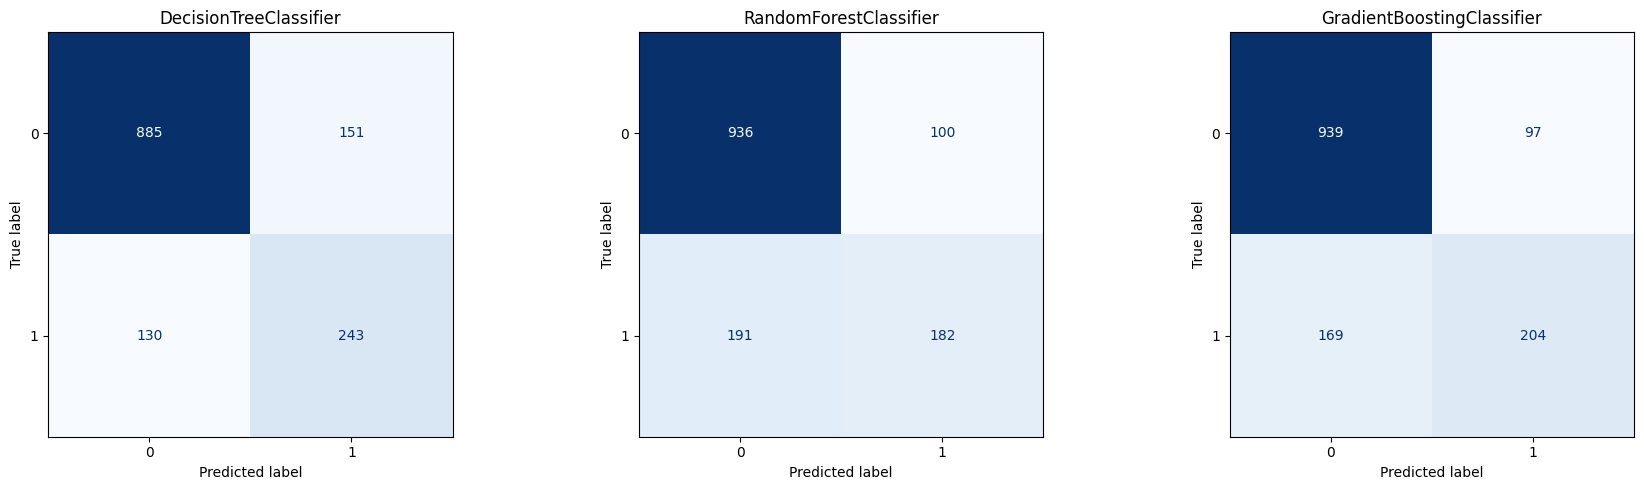

In [8]:
def plot_confusion_matrices(models: dict, X_test, y_test):
    fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

    if len(models) == 1:
        axes = [axes]

    for idx, (name, model) in enumerate(models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
        axes[idx].set_title(name)

    plt.tight_layout()
    plt.show()


plot_confusion_matrices(best_models, X_test, y_test)

### Визуализация ROC-кривых для всех моделей

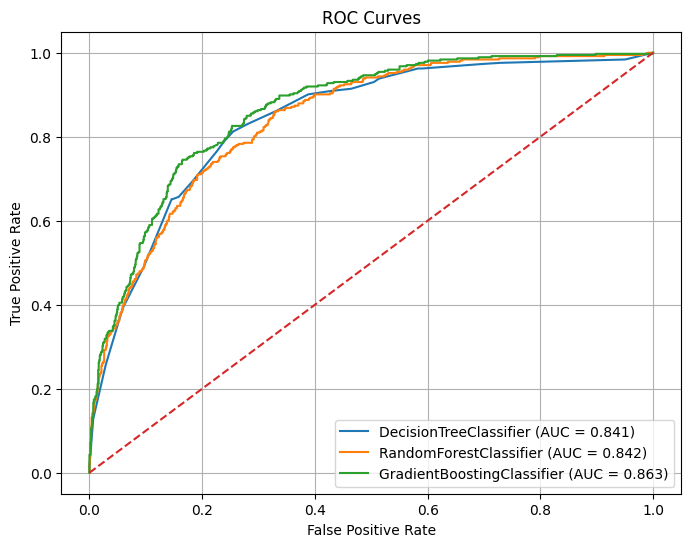

In [9]:
def plot_roc_curves(models: dict, X_test, y_test):
    plt.figure(figsize=(8, 6))

    for name, model in models.items():

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.grid()
    plt.show()


plot_roc_curves(best_models, X_test, y_test)

### Сводная таблица производительности

In [17]:
metrics_df = metrics_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True).round(3)

metrics_df

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,DecisionTreeClassifier,0.801,0.617,0.651,0.634,0.841
1,GradientBoostingClassifier,0.811,0.678,0.547,0.605,0.863
2,RandomForestClassifier,0.793,0.645,0.488,0.556,0.842


## Задание 5. Визуализация обученного дерева решений

Поскольку оптимальное дерево может быть слишком глубоким для визуализации, построим небольшое "дерево-прототип" с `max_depth=3`, чтобы наглядно увидеть логику принятия решений.

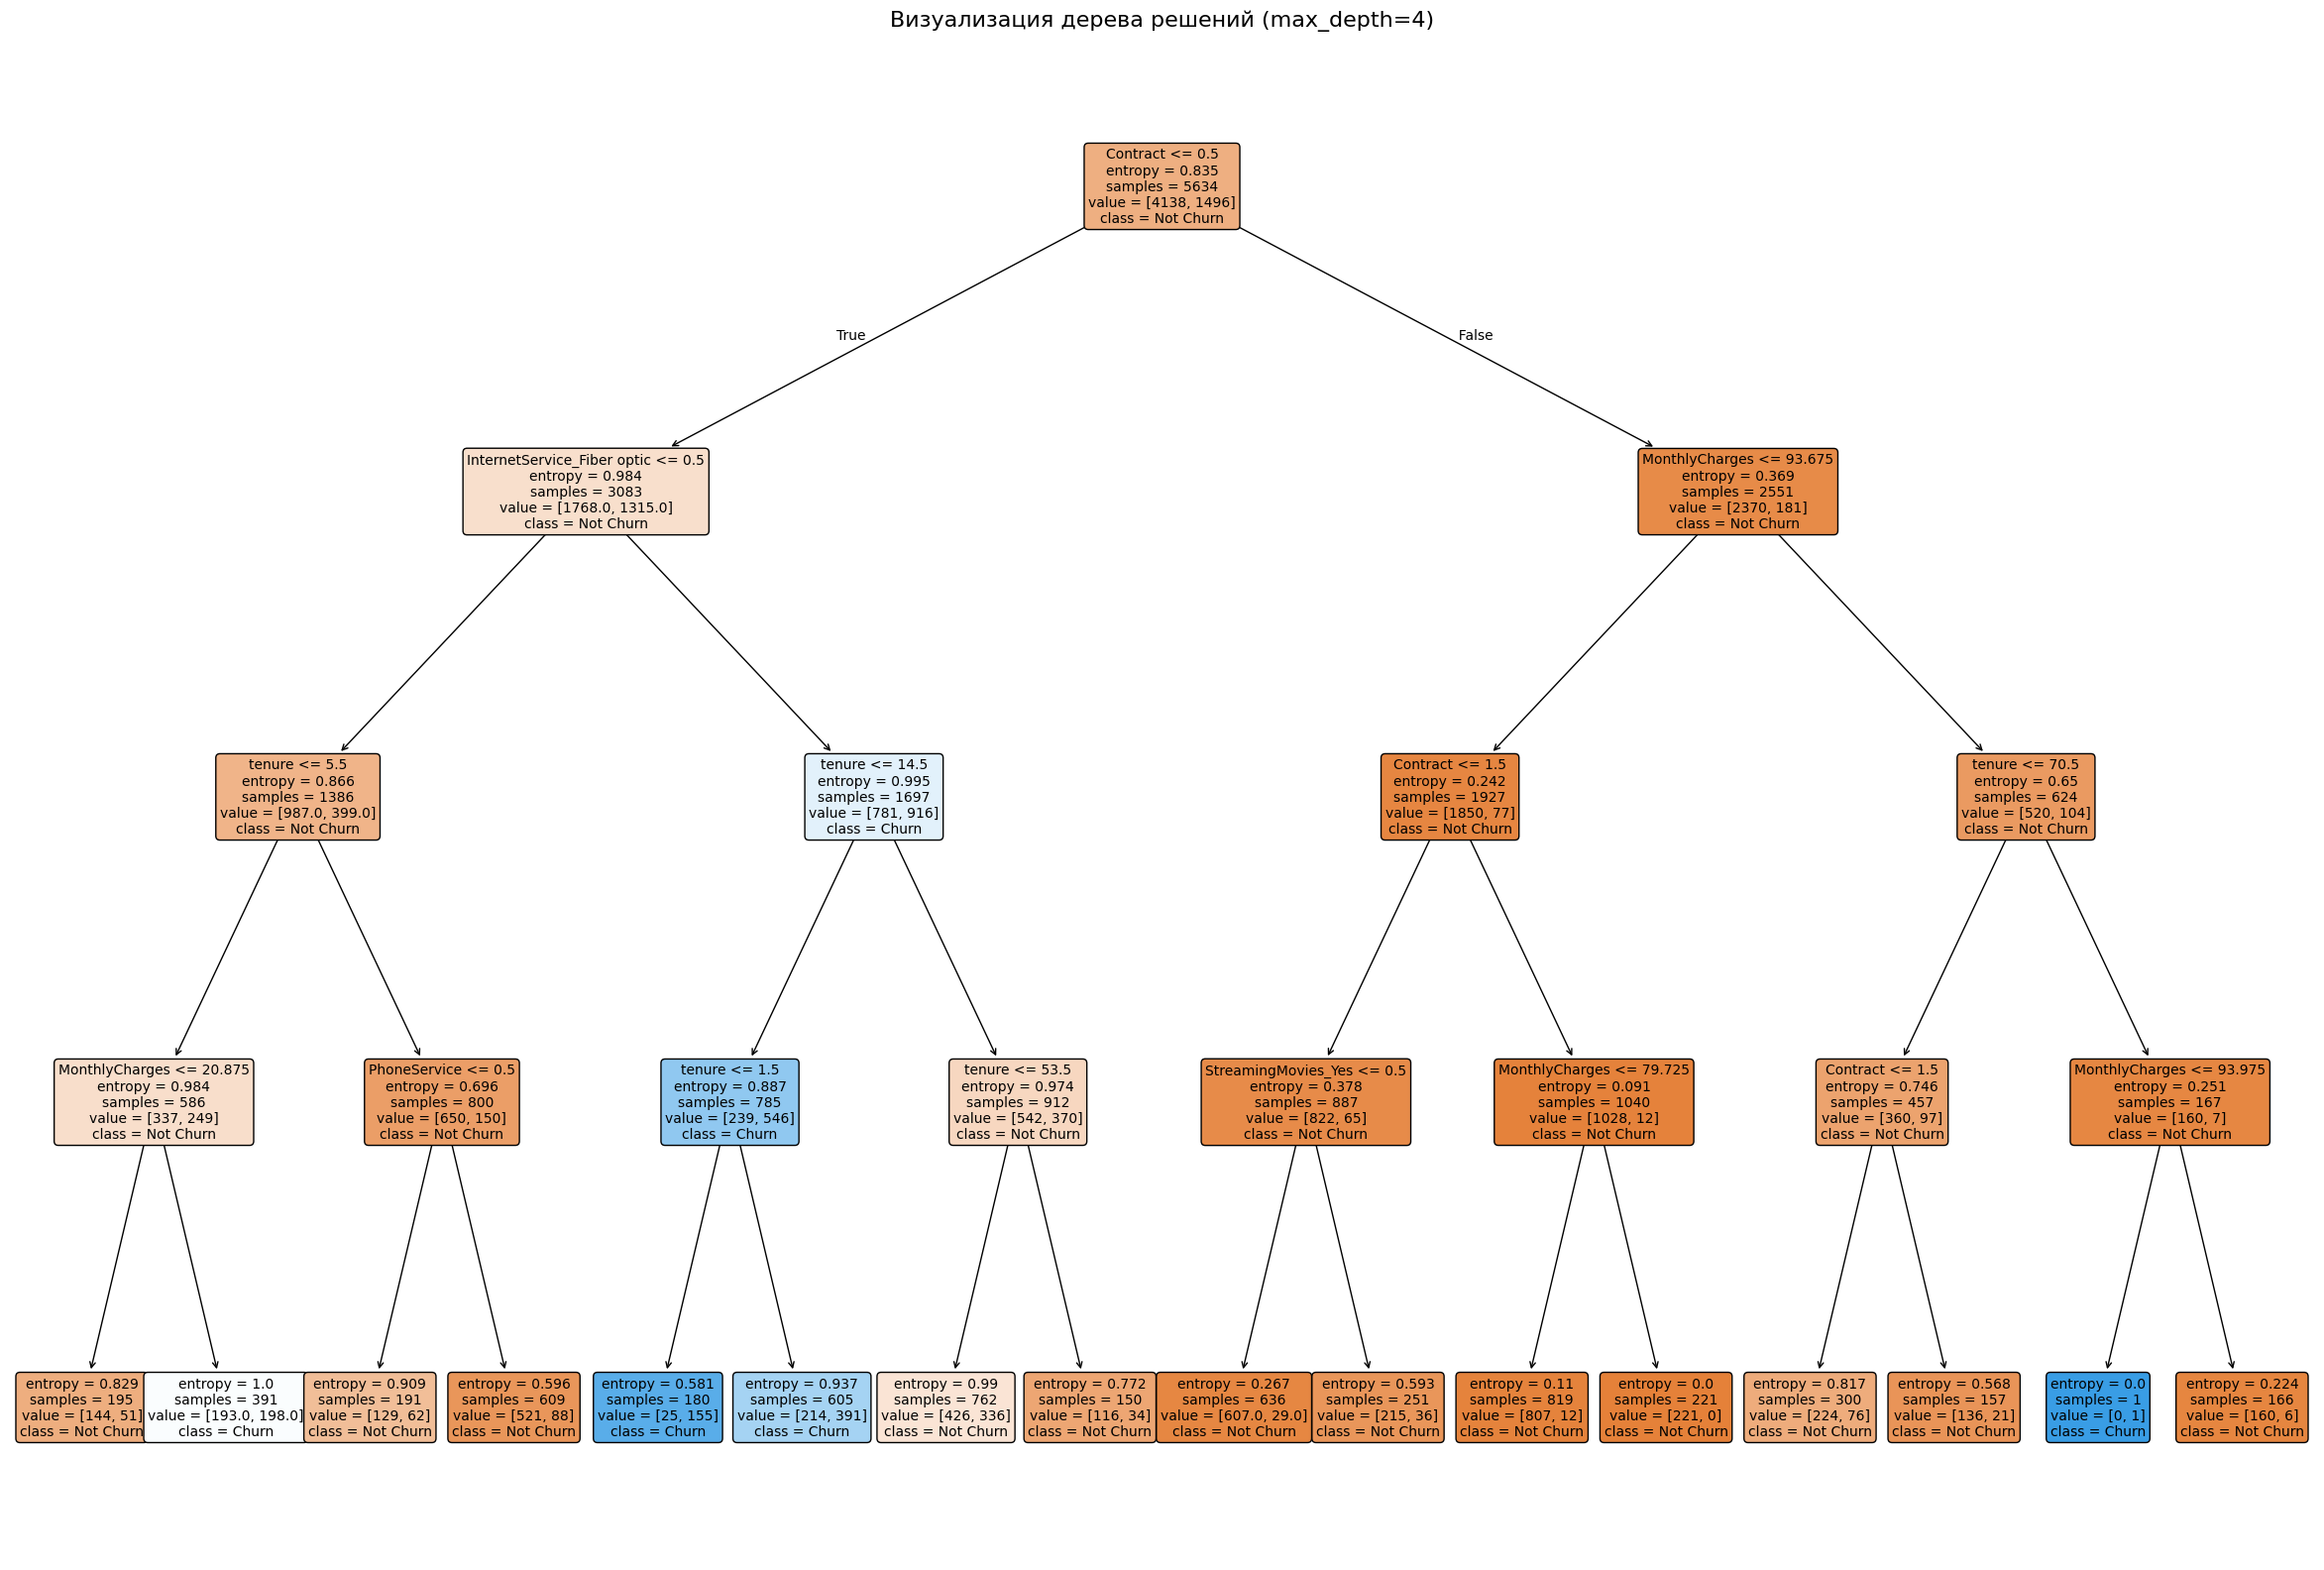

In [15]:
max_depth = 4
viz_tree = DecisionTreeClassifier(
    criterion=best_models["DecisionTreeClassifier"].criterion,
    max_depth=max_depth,
    random_state=42
)
viz_tree.fit(X_train, y_train)

plt.figure(figsize=(30, 20))
plot_tree(
    viz_tree,
    filled=True,
    rounded=True,
    feature_names=X_train.columns if hasattr(X_train, "columns") else None,
    class_names=["Not Churn", "Churn"],
    fontsize=10
)
plt.title(f"Визуализация дерева решений (max_depth={max_depth})", fontsize=16)
plt.show()

## Анализ и выводы

#### DecisionTreeClassifier

Модель `DecisionTreeClassifier` показала лучший результат по **F1-score (`0.634`)** и **Recall (`0.651`)**. Это означает, что дерево решений лучше остальных моделей обнаруживало клиентов, склонных к оттоку (`Churn`).

Также модель обладает высокой интерпретируемостью, так как структура решений представляется в виде понятного дерева правил. Однако одиночное дерево решений склонно к переобучению и может хуже обобщать данные на новых выборках.

---

#### RandomForestClassifier

Модель `RandomForestClassifier` показала худший результат по **F1-score (`0.556`)** и **Recall (`0.488`)**.

Несмотря на то, что случайный лес обычно снижает переобучение за счёт ансамбля деревьев, в данном наборе данных модель хуже определяла положительный класс.

Преимуществом `Random Forest` является устойчивость к шуму и более стабильная работа по сравнению с одиночным деревом, однако интерпретируемость модели значительно ниже.

---

#### GradientBoostingClassifier

Модель `GradientBoostingClassifier` достигла наилучших значений:

- **Accuracy (`0.811`)**
- **Precision (`0.678`)**
- **ROC AUC (`0.863`)**

Это говорит о хорошей способности модели разделять классы и уменьшать количество ложноположительных предсказаний.

`Gradient Boosting` строит ансамбль деревьев последовательно, исправляя ошибки предыдущих моделей, благодаря чему достигается высокое качество классификации.

Недостатками модели являются более длительное обучение и высокая чувствительность к гиперпараметрам.

---

### Влияние гиперпараметров

Гиперпараметры оказали заметное влияние на производительность моделей.

Для `DecisionTreeClassifier` оптимальной оказалась глубина дерева:

```python
max_depth = 5
```
что позволило снизить переобучение.

Для RandomForestClassifier лучшим значением стало:
```python
max_depth = 10
```
обеспечившее более сложную структуру ансамбля.

В GradientBoostingClassifier использование:

```python
max_depth = 3
max_features = 'sqrt'
```
позволило построить более устойчивую модель с хорошей обобщающей способностью.

**Итог**

Наиболее подходящей моделью для данного набора данных можно считать GradientBoostingClassifier, поскольку она показала лучшие значения Accuracy и ROC AUC, а также высокий уровень Precision.